This notebook is part of a Kaggle dataset [Bays and Gulfs of the World](https://www.kaggle.com/datasets/pnchowdhury/bays-and-gulfs-of-the-world) created in 2020. Through this code, you can visualize the location of Bays and Gulfs using the `geopandas` package. You can also create an interactive map using the `folium` package.


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from collections import Counter
from itertools import islice
import matplotlib.pyplot as plt
import folium

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/bays-and-gulfs-of-the-world/Bays and Gulfs.csv
/kaggle/input/shpfile/World_Map.dbf
/kaggle/input/shpfile/World_Map.prj
/kaggle/input/shpfile/World_Map.cpg
/kaggle/input/shpfile/World_Map.sbn
/kaggle/input/shpfile/World_Map.shx
/kaggle/input/shpfile/World_Map.sbx
/kaggle/input/shpfile/World_Map.shp


## **Exploring the Data File**
Let us take a look at our data. Though in kaggle dataset, the description of rows and columns can be found, it is a good practice to have a glimpse of the data using `head()` method. It shows the first five rows of the data file.

In [ ]:
data_file = pd.read_csv('../input/bays-and-gulfs-of-the-world/Bays and Gulfs.csv')
data_file.head()

,Ocean/Sea,Gulf/Bay,Longitude,Latitude,Country,Continent
0,Atlantic Ocean,Gulf of Guinea,3.732001,3.744211,"Ivory Coast, Ghana, Togo, Benin, Nigeria, Came...",Africa
1,Arabian Sea,Gulf of Aden,47.915624,12.541258,"Djibouti, Somalia,Yemen","Africa, Asia"
2,Arabian Sea,Gulf of Tadjoura,43.051716,11.723257,Djibouti,Africa
3,Mediterranean Sea,Abu Qir Bay,30.166592,31.300084,Egypt,Africa
4,Red Sea,Gulf of Aqaba,34.700906,28.760603,"Egypt, Israel, Jordan, Saudi Arabia","Africa, Asia"


The `read_csv()` method returns a DataFrame. To investigate in details about the DataFrame, we can use the `info()` method. This will show us some important aspects of the data e.g. data type, non-null values,  memory usage etc. In this case, we have 4 objects (strings) and 2 float64 type data in total 6 columns. The most important thing  to notice here is that there is no null values. Therefore, investigating with `info()` will make our life a bit easier.

In [ ]:
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ocean/Sea  232 non-null    object 
 1   Gulf/Bay   232 non-null    object 
 2   Longitude  232 non-null    float64
 3   Latitude   232 non-null    float64
 4   Country    232 non-null    object 
 5   Continent  232 non-null    object 
dtypes: float64(2), object(4)
memory usage: 11.0+ KB


## **Visualizing the Geospatial Data**

Firstly, we can see the world distribution of Gulfs and Bays. The Geopandas package is used here. We convert the DataFrame to a GeoDataFrame. We also need a world map shapefile. The Geopandas can read .shp file using the `read_file()` method.

<AxesSubplot:>

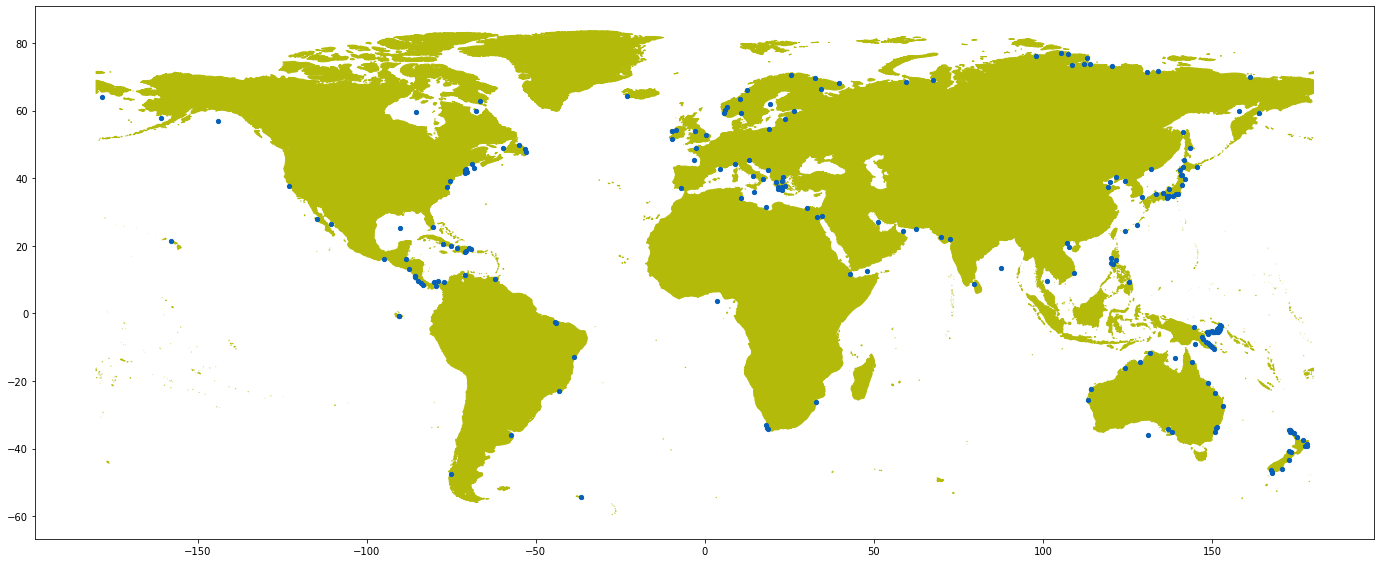

In [ ]:
# Define the dataset
world_map = gpd.read_file('../input/shpfile')
bays_gulfs = gpd.GeoDataFrame(data_file, geometry= gpd.points_from_xy(data_file.Longitude,data_file.Latitude))

# Define the basemap
base = world_map.plot(color='#B3BA0A', edgecolor='#B3BA0A',figsize=(24,24))

# Plot the data on the basemap
bays_gulfs.plot(ax = base,color='#085FB8',marker='o', markersize=18)

The blue dots are the locations of gulfs and bays. Africa seems to have the least ones. It is clear that Europe and Asia have the most inlets. Australia, Newzealand and Papua New Guienea are almost completely surrounded by bays. We can make this static map more interactive using `folium`.

## **Creating an Interactive Map**

The folium package makes it easy to create an interactive web map. We can show the locations of our inlets and display its attributes at the same time.

In [ ]:
# Define the basemap
world_map = folium.Map(location=[10.5,5.10], zoom_start=2,  tiles='openstreetmap')

# Define a function to attach the attributes to a folium marker
def plotBay(d_f):
    folium.Marker(location=[d_f.Latitude, d_f.Longitude], popup=d_f['Gulf/Bay']+' in\n'+ d_f['Ocean/Sea'],icon=folium.Icon( icon='info-sign')).add_to(world_map)

# Call the plotBay() function
# Using apply() because we need access to multiple columns of the dataframe
data_file.apply(plotBay,axis=1)
world_map


If you click on the markers, you can see the name of the gulf/bay and which sea or ocean it belongs to. The `popup` parameter makes it possible.

## **The Numbers**

Lastly, let us explore the number of bays and their surrounding continents. Here we will use the `matplotlib.pyplot` package and create a bar chart. We will try to find which continent has the most gulfs/bays.

The graph indicates that most of the bays and gulfs are assosicated with Asia. As we get back to our map, we can see that Asia and Oceania do have higher number of bays and gulfs than all other continets. Interestingly, the North America and Europe have almost equal number of inlets.

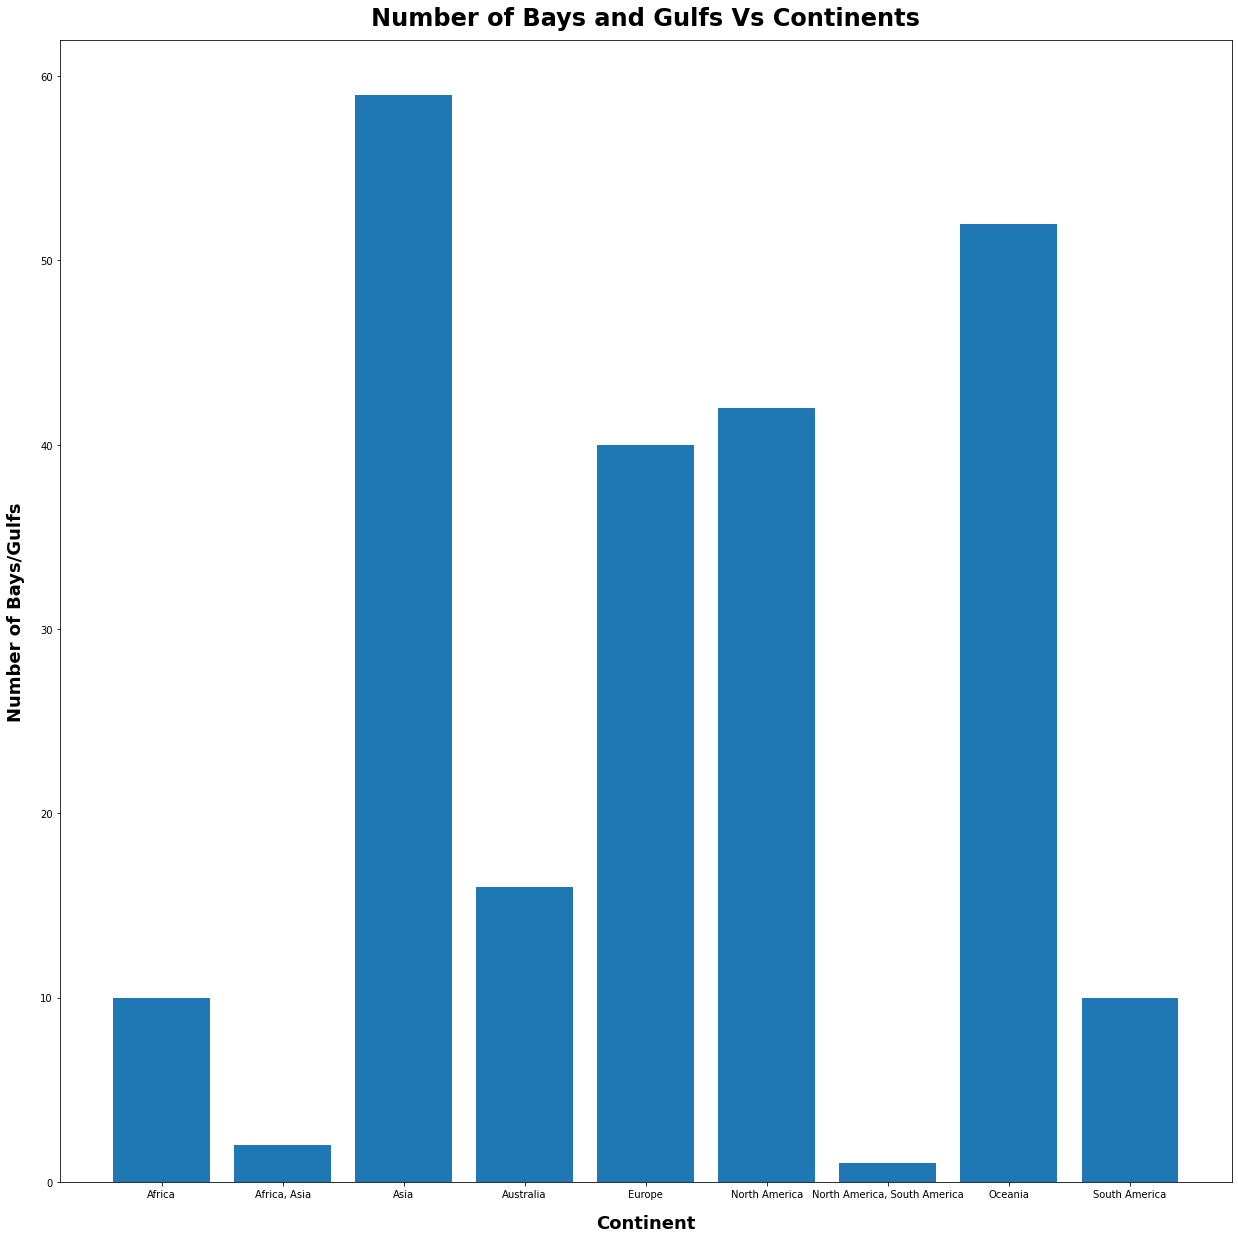

In [ ]:
# Count the number of Bays and Gulfs in each continent
dict_continent = Counter(data_file['Continent'])

plt.figure(figsize=(21,21))
plt.bar(dict_continent.keys(),dict_continent.values())
plt.title('Number of Bays and Gulfs Vs Continents',pad=15,fontdict={'fontsize': 24,'fontweight':'bold'})
plt.xlabel(xlabel="Continent",labelpad=15, fontdict={'fontsize': 18,'fontweight':'bold'})
plt.ylabel(ylabel="Number of Bays/Gulfs",labelpad=15,fontdict={'fontsize': 18,'fontweight':'bold'})
plt.show()